# User Analytics in the Telecommunication Industry

In [3]:
import pandas as pd
df = pd.read_excel('/content/telcom_data (2).xlsx')
print('Shape:', df.shape)
df.head()

Shape: (150001, 55)


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


* Standardizing the column names

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace("/", "_", regex=False)
)

df.columns.tolist()

['bearer_id',
 'start',
 'start_ms',
 'end',
 'end_ms',
 'dur_ms',
 'imsi',
 'msisdn_number',
 'imei',
 'last_location_name',
 'avg_rtt_dl_ms',
 'avg_rtt_ul_ms',
 'avg_bearer_tp_dl_kbps',
 'avg_bearer_tp_ul_kbps',
 'tcp_dl_retrans_vol_bytes',
 'tcp_ul_retrans_vol_bytes',
 'dl_tp_<_50_kbps_%',
 '50_kbps_<_dl_tp_<_250_kbps_%',
 '250_kbps_<_dl_tp_<_1_mbps_%',
 'dl_tp_>_1_mbps_%',
 'ul_tp_<_10_kbps_%',
 '10_kbps_<_ul_tp_<_50_kbps_%',
 '50_kbps_<_ul_tp_<_300_kbps_%',
 'ul_tp_>_300_kbps_%',
 'http_dl_bytes',
 'http_ul_bytes',
 'activity_duration_dl_ms',
 'activity_duration_ul_ms',
 'dur_ms1',
 'handset_manufacturer',
 'handset_type',
 'nb_of_sec_with_125000b_<_vol_dl',
 'nb_of_sec_with_1250b_<_vol_ul_<_6250b',
 'nb_of_sec_with_31250b_<_vol_dl_<_125000b',
 'nb_of_sec_with_37500b_<_vol_ul',
 'nb_of_sec_with_6250b_<_vol_dl_<_31250b',
 'nb_of_sec_with_6250b_<_vol_ul_<_37500b',
 'nb_of_sec_with_vol_dl_<_6250b',
 'nb_of_sec_with_vol_ul_<_1250b',
 'social_media_dl_bytes',
 'social_media_ul_bytes',


In [5]:
import numpy as np
df = df.replace('undefined',np.nan)

In [6]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
nb_of_sec_with_37500b_<_vol_ul,130254
nb_of_sec_with_6250b_<_vol_ul_<_37500b,111843
nb_of_sec_with_125000b_<_vol_dl,97538
tcp_ul_retrans_vol_bytes,96649
nb_of_sec_with_31250b_<_vol_dl_<_125000b,93586
nb_of_sec_with_1250b_<_vol_ul_<_6250b,92894
nb_of_sec_with_6250b_<_vol_dl_<_31250b,88317
tcp_dl_retrans_vol_bytes,88146
http_ul_bytes,81810
http_dl_bytes,81474


* Converting date columns

In [7]:
df['start'] = pd.to_datetime(df['start'],errors='coerce')
df['end'] = pd.to_datetime(df['end'],errors='coerce')

In [8]:
df[["start", "end"]].dtypes

,0
start,datetime64[ns]
end,datetime64[ns]


* Refinement of the columns

In [9]:
df["total_traffic_bytes"] = (
    df["total_dl_bytes"] + df["total_ul_bytes"]
)

In [10]:
df["social_media_total"] = (
    df["social_media_dl_bytes"] +
    df["social_media_ul_bytes"]
)

df["google_total"] = (
    df["google_dl_bytes"] +
    df["google_ul_bytes"]
)

df["email_total"] = (
    df["email_dl_bytes"] +
    df["email_ul_bytes"]
)

df["youtube_total"] = (
    df["youtube_dl_bytes"] +
    df["youtube_ul_bytes"]
)

df["netflix_total"] = (
    df["netflix_dl_bytes"] +
    df["netflix_ul_bytes"]
)

df["gaming_total"] = (
    df["gaming_dl_bytes"] +
    df["gaming_ul_bytes"]
)

df["other_total"] = (
    df["other_dl_bytes"] +
    df["other_ul_bytes"]
)

* Checking for duplicate sessions

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['bearer_id'].duplicated().sum()

np.int64(15292)

* Treating Missing Values

In [13]:

missing = df.isna().sum().sort_values(ascending=False)

missing[missing > 0]

,0
nb_of_sec_with_37500b_<_vol_ul,130254
nb_of_sec_with_6250b_<_vol_ul_<_37500b,111843
nb_of_sec_with_125000b_<_vol_dl,97538
tcp_ul_retrans_vol_bytes,96649
nb_of_sec_with_31250b_<_vol_dl_<_125000b,93586
nb_of_sec_with_1250b_<_vol_ul_<_6250b,92894
nb_of_sec_with_6250b_<_vol_dl_<_31250b,88317
tcp_dl_retrans_vol_bytes,88146
http_ul_bytes,81810
http_dl_bytes,81474


In [14]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
nb_of_sec_with_37500b_<_vol_ul,130254,86.84
nb_of_sec_with_6250b_<_vol_ul_<_37500b,111843,74.56
nb_of_sec_with_125000b_<_vol_dl,97538,65.02
tcp_ul_retrans_vol_bytes,96649,64.43
nb_of_sec_with_31250b_<_vol_dl_<_125000b,93586,62.39
nb_of_sec_with_1250b_<_vol_ul_<_6250b,92894,61.93
nb_of_sec_with_6250b_<_vol_dl_<_31250b,88317,58.88
tcp_dl_retrans_vol_bytes,88146,58.76
http_ul_bytes,81810,54.54
http_dl_bytes,81474,54.32


In [15]:
# Filling categorical missing values with the mode

categorical_cols = [
    "handset_manufacturer",
    "handset_type",
    "last_location_name"
]

for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

print("Categorical missing values handled.")

Categorical missing values handled.


In [16]:
df[categorical_cols].isna().sum()

,0
handset_manufacturer,0
handset_type,0
last_location_name,0


* Handling customer identifiers

In [17]:
identifier_cols = [
    "imsi",
    "msisdn_number",
    "imei"
]

df[identifier_cols].isna().sum()

,0
imsi,570
msisdn_number,1066
imei,572


In [18]:
numeric_cols = df.select_dtypes(include="number").columns

print("Number of numeric columns:", len(numeric_cols))

Number of numeric columns: 57


In [19]:
numeric_missing = df[numeric_cols].isna().sum()

numeric_missing[numeric_missing > 0].sort_values(ascending=False)

,0
nb_of_sec_with_37500b_<_vol_ul,130254
nb_of_sec_with_6250b_<_vol_ul_<_37500b,111843
nb_of_sec_with_125000b_<_vol_dl,97538
tcp_ul_retrans_vol_bytes,96649
nb_of_sec_with_31250b_<_vol_dl_<_125000b,93586
nb_of_sec_with_1250b_<_vol_ul_<_6250b,92894
nb_of_sec_with_6250b_<_vol_dl_<_31250b,88317
tcp_dl_retrans_vol_bytes,88146
http_ul_bytes,81810
http_dl_bytes,81474


In [20]:
identifier_cols = [
    "imsi",
    "msisdn_number",
    "imei"
]

# Numeric columns excluding identifiers
numeric_fill_cols = [
    col for col in numeric_cols
    if col not in identifier_cols
]

print("Numeric columns to fill:", len(numeric_fill_cols))

Numeric columns to fill: 54


In [21]:
for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Numeric missing values filled.")

Numeric missing values filled.


In [22]:
remaining_missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing[remaining_missing > 0]

,0
msisdn_number,1066
imei,572
imsi,570
end,1
start,1


In [23]:
before = len(df)

df = df.dropna(subset=["msisdn_number"])

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 150001
Rows after: 148935
Rows removed: 1066


In [24]:
missing_after = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

missing_after = missing_after[
    missing_after["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

missing_after

,missing_count,missing_percentage


* Checking Duplicate Records

In [25]:
duplicate_rows = df.duplicated().sum()

print("Completely duplicated rows:", duplicate_rows)

Completely duplicated rows: 0


In [26]:
duplicate_bearers = df["bearer_id"].duplicated().sum()

print("Duplicate Bearer IDs:", duplicate_bearers)

Duplicate Bearer IDs: 14679


In [27]:
print("Current dataset shape:", df.shape)

Current dataset shape: (148935, 63)


* Checking of the outliers

In [28]:
important_numeric = [
    "dur_ms",
    "avg_rtt_dl_ms",
    "avg_rtt_ul_ms",
    "avg_bearer_tp_dl_kbps",
    "avg_bearer_tp_ul_kbps",
    "total_dl_bytes",
    "total_ul_bytes",
    "total_traffic_bytes"
]

df[important_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
dur_ms,148935.0,1.048702e+05,8.106343e+04,7142.0,57883.5,86399.0,1.327000e+05,1859336.0
avg_rtt_dl_ms,148935.0,1.085163e+02,5.363170e+02,0.0,35.0,54.0,1.097957e+02,96923.0
avg_rtt_ul_ms,148935.0,1.764199e+01,7.652615e+01,0.0,3.0,7.0,1.766288e+01,7120.0
avg_bearer_tp_dl_kbps,148935.0,1.328617e+04,2.397859e+04,0.0,43.0,63.0,1.968100e+04,378160.0
avg_bearer_tp_ul_kbps,148935.0,1.770786e+03,4.629476e+03,0.0,47.0,63.0,1.117000e+03,58613.0
total_dl_bytes,148935.0,4.546251e+08,2.441528e+08,7114041.0,243099622.5,455870838.0,6.656577e+08,902969616.0
total_ul_bytes,148935.0,4.111764e+07,1.127933e+07,2866892.0,33217740.5,41141014.0,4.903248e+07,78331311.0
total_traffic_bytes,148935.0,4.957428e+08,2.443876e+08,28956107.0,284464070.5,496846039.0,7.064483e+08,955984776.0


In [29]:
outlier_summary = []

for col in important_numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,dur_ms,57883.5,1.327000e+05,7.481650e+04,-5.434125e+04,2.449248e+05,7149,4.80
1,avg_rtt_dl_ms,35.0,1.097957e+02,7.479571e+01,-7.719356e+01,2.219893e+02,7563,5.08
2,avg_rtt_ul_ms,3.0,1.766288e+01,1.466288e+01,-1.899432e+01,3.965721e+01,8912,5.98
3,avg_bearer_tp_dl_kbps,43.0,1.968100e+04,1.963800e+04,-2.941400e+04,4.913800e+04,13202,8.86
4,avg_bearer_tp_ul_kbps,47.0,1.117000e+03,1.070000e+03,-1.558000e+03,2.722000e+03,21417,14.38
5,total_dl_bytes,243099622.5,6.656577e+08,4.225580e+08,-3.907374e+08,1.299495e+09,0,0.00
6,total_ul_bytes,33217740.5,4.903248e+07,1.581474e+07,9.495637e+06,7.275458e+07,241,0.16
7,total_traffic_bytes,284464070.5,7.064483e+08,4.219842e+08,-3.485123e+08,1.339425e+09,0,0.00


In [30]:
# Check whether bearer_id was accidentally mean-imputed
df['bearer_id'] = pd.to_numeric(df['bearer_id'], errors='coerce')

bearer_mean = df['bearer_id'].mean()
print('Bearer ID Mean:', bearer_mean)
print('Rows equal to the imputed mean:')
print((df['bearer_id'] == bearer_mean.sum()))

Bearer ID Mean: 1.014675765016463e+19
Rows equal to the imputed mean:
0         False
1         False
2         False
3         False
4         False
          ...  
149995    False
149996    False
149997    False
149998    False
149999    False
Name: bearer_id, Length: 148935, dtype: bool


In [31]:
# Restore accidentally mean-imputed Bearer IDs to missing

df.loc[df["bearer_id"] == bearer_mean, "bearer_id"] = np.nan

print("Remaining missing Bearer IDs:",
      df["bearer_id"].isna().sum())

Remaining missing Bearer IDs: 429


In [32]:
print("Final rows:", len(df))
print("Final columns:", len(df.columns))

print("\nMissing values:")
print(df.isna().sum().sum())

print("\nCompletely duplicated rows:")
print(df.duplicated().sum())

Final rows: 148935
Final columns: 63

Missing values:
429

Completely duplicated rows:
0


In [33]:
import os

clean_path = "../data/processed/telecom_clean.csv"

os.makedirs(os.path.dirname(clean_path),exist_ok=True)

df.to_csv(clean_path, index=False)

print("Clean dataset saved successfully")
print(clean_path)

Clean dataset saved successfully
../data/processed/telecom_clean.csv


### Key Insights from Data Preprocessing

- The original telecom dataset contained 150,000 records and 55 columns.
- After data cleaning and preprocessing, the dataset contained 148,935 records and 63 columns.
- The `undefined` values were converted to missing values and handled appropriately during preprocessing.
- Missing customer IDs were removed because customer-level analysis requires a valid customer identifier.
- Duplicate full records were not present in the dataset.
- Missing `bearer_id` values were retained because this field is not required for customer-level aggregation.
- Outliers were not automatically removed because unusually high telecom usage or network measurements may represent genuine customer behavior.
- These preprocessing steps provided a consistent dataset for customer-level engagement, experience, and satisfaction analysis.

Task 1 - User Overview

* Top 10 Handsets

In [34]:
top_10_handsets = (
    df["handset_type"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_handsets.columns = [
    "handset_type",
    "number_of_users"
]

top_10_handsets

,handset_type,number_of_users
0,Huawei B528S-23A,28658
1,Apple iPhone 6S (A1688),9413
2,Apple iPhone 6 (A1586),9012
3,Apple iPhone 7 (A1778),6304
4,Apple iPhone Se (A1723),5176
5,Apple iPhone 8 (A1905),4985
6,Apple iPhone Xr (A2105),4562
7,Samsung Galaxy S8 (Sm-G950F),4480
8,Apple iPhone X (A1901),3810
9,Samsung Galaxy A5 Sm-A520F,3708


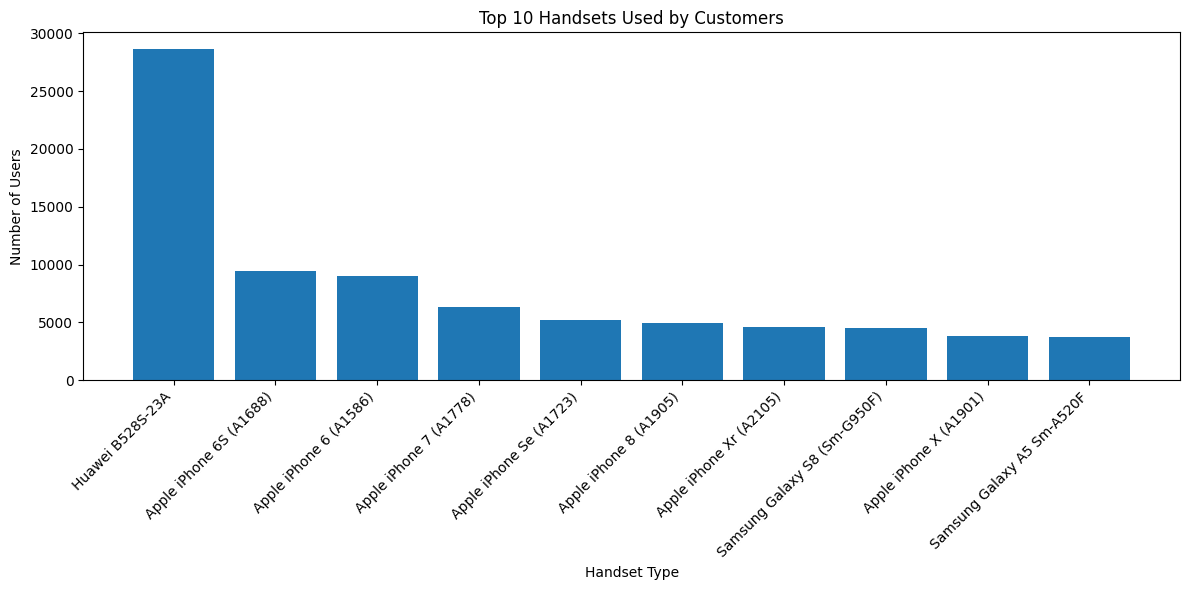

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_handsets["handset_type"],
    top_10_handsets["number_of_users"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Handset Type")
plt.ylabel("Number of Users")
plt.title("Top 10 Handsets Used by Customers")

plt.tight_layout()
plt.show()

* Top 3 Handset Manufacturers

In [36]:
top_3_manufacturers = (
    df["handset_manufacturer"]
    .value_counts()
    .head(3)
    .reset_index()
)

top_3_manufacturers.columns = [
    "handset_manufacturer",
    "number_of_users"
]

print(top_3_manufacturers.to_string(index=False))

handset_manufacturer  number_of_users
               Apple            68395
             Samsung            40579
              Huawei            34366


* Top 5 Handsets from Top 3 Manufacturers

In [37]:
top_3_names = top_3_manufacturers["handset_manufacturer"].tolist()

for manufacturer in top_3_names:
    print("\n" + "=" * 60)
    print(f"Top 5 handsets for {manufacturer}")
    print("=" * 60)

    result = (
        df[df["handset_manufacturer"] == manufacturer]["handset_type"]
        .value_counts()
        .head(5)
        .reset_index()
    )

    result.columns = ["handset_type", "number_of_users"]

    print(result.to_string(index=False))


Top 5 handsets for Apple
           handset_type  number_of_users
Apple iPhone 6S (A1688)             9413
 Apple iPhone 6 (A1586)             9012
       Huawei B528S-23A             8931
 Apple iPhone 7 (A1778)             6304
Apple iPhone Se (A1723)             5176

Top 5 handsets for Samsung
                handset_type  number_of_users
Samsung Galaxy S8 (Sm-G950F)             4480
  Samsung Galaxy A5 Sm-A520F             3708
 Samsung Galaxy J5 (Sm-J530)             3682
 Samsung Galaxy J3 (Sm-J330)             3464
Samsung Galaxy S7 (Sm-G930X)             3176

Top 5 handsets for Huawei
                  handset_type  number_of_users
              Huawei B528S-23A            19727
                  Huawei E5180             2074
Huawei P20 Lite Huawei Nova 3E             2018
                    Huawei P20             1479
                Huawei Y6 2018              997


### Key Insights from Handset Analysis

- Huawei B528S-23A was the most frequently observed handset type, with 28,658 users.
- Apple had the highest number of users among the three major manufacturers considered, with 68,395 users, followed by Samsung with 40,579 and Huawei with 34,366.
- Apple iPhone 6S (A1688) and Apple iPhone 6 (A1586) were among the most frequently observed handset models.
- Huawei B528S-23A had a particularly large user base and therefore represents an important handset for customer and network analysis.
- The handset/manufacturer results also revealed a data-quality anomaly: Huawei B528S-23A appears under the Apple manufacturer grouping for some records. This inconsistency was retained rather than manually corrected because there was insufficient evidence to determine the correct manufacturer for those records.

* Customer Level Dataset

In [38]:
customer_overview = (
    df.groupby("msisdn_number")
      .agg(
          session_frequency=("msisdn_number", "size"),
          total_session_duration_ms=("dur_ms", "sum"),
          total_dl_bytes=("total_dl_bytes", "sum"),
          total_ul_bytes=("total_ul_bytes", "sum"),
          total_traffic_bytes=("total_traffic_bytes", "sum")
      )
      .reset_index()
)

customer_overview.head()

,msisdn_number,session_frequency,total_session_duration_ms,total_dl_bytes,total_ul_bytes,total_traffic_bytes
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,8.786906e+08
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,1.568596e+08
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,5.959665e+08
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,4.223207e+08
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,1.457411e+09


In [39]:
print("Number of customers:", len(customer_overview))
print("Columns:", customer_overview.columns.tolist())

Number of customers: 106856
Columns: ['msisdn_number', 'session_frequency', 'total_session_duration_ms', 'total_dl_bytes', 'total_ul_bytes', 'total_traffic_bytes']


In [40]:
customer_overview.describe()

,msisdn_number,session_frequency,total_session_duration_ms,total_dl_bytes,total_ul_bytes,total_traffic_bytes
count,1.068560e+05,106856.000000,1.068560e+05,1.068560e+05,1.068560e+05,1.068560e+05
mean,4.511474e+10,1.393792,1.461672e+05,6.336527e+08,5.730942e+07,6.909621e+08
std,2.889423e+12,0.806022,1.863587e+05,4.645551e+08,3.565765e+07,4.910559e+08
min,3.360100e+10,1.000000,7.142000e+03,8.827082e+06,2.866892e+06,3.324901e+07
25%,3.365088e+10,1.000000,7.130800e+04,3.148271e+08,3.639547e+07,3.585499e+08
50%,3.366365e+10,1.000000,1.027400e+05,5.703677e+08,4.679387e+07,6.179231e+08
75%,3.368344e+10,2.000000,1.727990e+05,8.073645e+08,6.573199e+07,8.574351e+08
max,8.823971e+14,18.000000,1.855375e+07,8.156743e+09,7.295774e+08,8.846226e+09


* Customer Level Application Traffic

In [41]:
application_usage = (
    df.groupby("msisdn_number")[
        [
            "social_media_total",
            "google_total",
            "email_total",
            "youtube_total",
            "netflix_total",
            "gaming_total",
            "other_total"
        ]
    ]
    .sum()
    .reset_index()
)

customer_overview = customer_overview.drop(
    columns=[
        "social_media_bytes",
        "google_bytes",
        "email_bytes",
        "youtube_bytes",
        "netflix_bytes",
        "gaming_bytes",
        "other_bytes"
    ],
    errors="ignore"
)

customer_overview = customer_overview.merge(
    application_usage,
    on="msisdn_number",
    how="left"
)

customer_overview.head()

,msisdn_number,session_frequency,total_session_duration_ms,total_dl_bytes,total_ul_bytes,total_traffic_bytes,social_media_total,google_total,email_total,youtube_total,netflix_total,gaming_total,other_total
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,8.786906e+08,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,1.568596e+08,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,5.959665e+08,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,4.223207e+08,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,1.457411e+09,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0


In [42]:
application_totals = (
    customer_overview[
        [
            "social_media_total",
            "google_total",
            "email_total",
            "youtube_total",
            "netflix_total",
            "gaming_total",
            "other_total"
        ]
    ]
    .sum()
    .sort_values(ascending=False)
)

print(application_totals)

gaming_total          6.408892e+13
other_total           6.395425e+13
youtube_total         3.372204e+12
netflix_total         3.370060e+12
google_total          1.162853e+12
email_total           3.364677e+11
social_media_total    2.722655e+11
dtype: float64


* Correlation Analysis

In [43]:
correlation_columns = [
    "session_frequency",
    "total_session_duration_ms",
    "total_traffic_bytes",
    "social_media_total",
    "google_total",
    "email_total",
    "youtube_total",
    "netflix_total",
    "gaming_total",
    "other_total"
]

correlation_matrix = customer_overview[correlation_columns].corr()

correlation_matrix.round(2)

,session_frequency,total_session_duration_ms,total_traffic_bytes,social_media_total,google_total,email_total,youtube_total,netflix_total,gaming_total,other_total
session_frequency,1.00,0.64,0.81,0.77,0.84,0.82,0.86,0.86,0.77,0.77
total_session_duration_ms,0.64,1.00,0.52,0.49,0.53,0.53,0.55,0.54,0.49,0.49
total_traffic_bytes,0.81,0.52,1.00,0.62,0.68,0.66,0.71,0.71,1.00,0.62
social_media_total,0.77,0.49,0.62,1.00,0.64,0.63,0.66,0.66,0.59,0.59
google_total,0.84,0.53,0.68,0.64,1.00,0.69,0.72,0.72,0.64,0.64
email_total,0.82,0.53,0.66,0.63,0.69,1.00,0.70,0.71,0.63,0.63
youtube_total,0.86,0.55,0.71,0.66,0.72,0.70,1.00,0.74,0.66,0.66
netflix_total,0.86,0.54,0.71,0.66,0.72,0.71,0.74,1.00,0.66,0.66
gaming_total,0.77,0.49,1.00,0.59,0.64,0.63,0.66,0.66,1.00,0.59
other_total,0.77,0.49,0.62,0.59,0.64,0.63,0.66,0.66,0.59,1.00


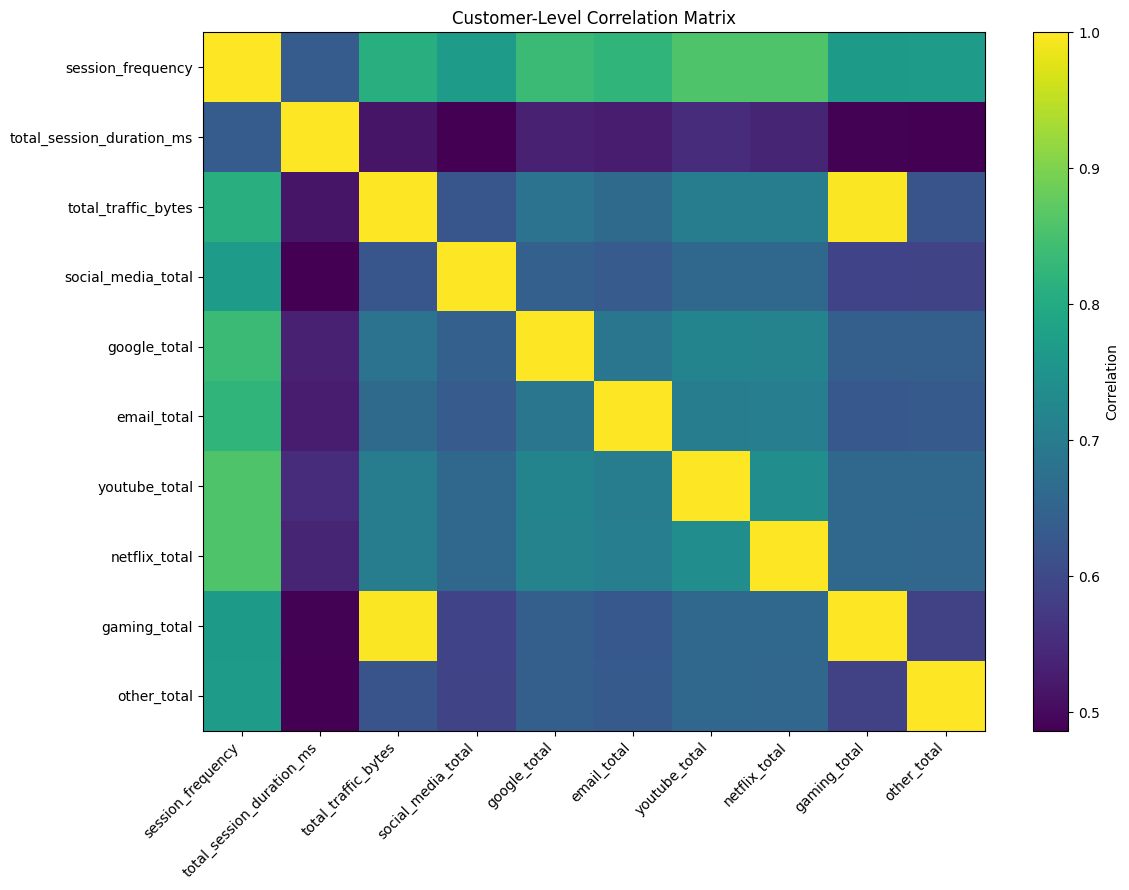

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.imshow(correlation_matrix, aspect="auto")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Customer-Level Correlation Matrix")

plt.tight_layout()
plt.show()

### Key Insights from Correlation Analysis

- Session frequency has a strong positive relationship with total traffic, with a correlation of approximately 0.81.
- Session frequency also has a positive relationship with total session duration, with a correlation of approximately 0.64.
- Total session duration and total traffic have a moderate positive correlation of approximately 0.52.
- Total traffic is extremely strongly correlated with gaming traffic, with a correlation of approximately 0.997.
- The strong relationship between session frequency and total traffic indicates that customers with more sessions generally generate higher overall traffic.
- The strong relationship between total traffic and gaming traffic suggests that gaming contributes substantially to overall customer traffic in this dataset.

In [45]:
print(
    customer_overview[
        ["total_traffic_bytes", "gaming_total"]
    ].corr()
)

print(
    customer_overview[
        ["total_traffic_bytes", "gaming_total"]
    ].describe()
)

                     total_traffic_bytes  gaming_total
total_traffic_bytes             1.000000      0.997001
gaming_total                    0.997001      1.000000
       total_traffic_bytes  gaming_total
count         1.068560e+05  1.068560e+05
mean          6.909621e+08  5.997690e+08
std           4.910559e+08  4.491505e+08
min           3.324901e+07  3.063580e+05
25%           3.585499e+08  2.880631e+08
50%           6.179231e+08  5.423492e+08
75%           8.574351e+08  7.773041e+08
max           8.846226e+09  7.749432e+09


In [46]:
difference = (
    customer_overview["total_traffic_bytes"]
    - customer_overview["gaming_total"]
)

print(difference.describe())

count    1.068560e+05
mean     9.119309e+07
std      5.548989e+07
min      1.266023e+07
25%      5.948110e+07
50%      7.261766e+07
75%      1.063338e+08
max      1.172947e+09
dtype: float64


In [47]:
print(
    customer_overview[
        ["total_traffic_bytes", "gaming_total"]
    ].corr()
)

print(
    customer_overview[
        ["total_traffic_bytes", "gaming_total"]
    ].head(10)
)

print(
    customer_overview[
        ["total_traffic_bytes", "gaming_total"]
    ].describe()
)

                     total_traffic_bytes  gaming_total
total_traffic_bytes             1.000000      0.997001
gaming_total                    0.997001      1.000000
   total_traffic_bytes  gaming_total
0         8.786906e+08  8.124587e+08
1         1.568596e+08  1.197501e+08
2         5.959665e+08  5.388277e+08
3         4.223207e+08  3.911261e+08
4         1.457411e+09  1.314798e+09
5         6.152172e+08  5.116358e+08
6         6.547231e+08  5.484611e+08
7         3.326604e+08  2.823644e+08
8         9.901322e+08  8.330880e+08
9         7.324638e+08  6.470957e+08
       total_traffic_bytes  gaming_total
count         1.068560e+05  1.068560e+05
mean          6.909621e+08  5.997690e+08
std           4.910559e+08  4.491505e+08
min           3.324901e+07  3.063580e+05
25%           3.585499e+08  2.880631e+08
50%           6.179231e+08  5.423492e+08
75%           8.574351e+08  7.773041e+08
max           8.846226e+09  7.749432e+09


* PCA

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_columns = [
    "session_frequency",
    "total_session_duration_ms",
    "total_traffic_bytes",
    "social_media_total",
    "google_total",
    "email_total",
    "youtube_total",
    "netflix_total",
    "gaming_total",
    "other_total"
]

scaler = StandardScaler()

pca_scaled = scaler.fit_transform(
    customer_overview[pca_columns]
)

pca = PCA()

pca_result = pca.fit_transform(pca_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_variance)

print("\nCumulative explained variance:")
print(explained_variance.cumsum())

Explained variance ratio:
[7.06155229e-01 6.79520134e-02 5.63156182e-02 4.08331408e-02
 3.73248348e-02 3.13377878e-02 2.86489974e-02 2.61231436e-02
 5.30209780e-03 7.13701452e-06]

Cumulative explained variance:
[0.70615523 0.77410724 0.83042286 0.871256   0.90858084 0.93991862
 0.96856762 0.99469077 0.99999286 1.        ]


### Key Insights from PCA

- The first principal component explains approximately 70.62% of the total variance.
- The first two principal components together explain approximately 77.41% of the variance.
- The first five principal components explain approximately 90.86% of the total variance.
- The first principal component has positive contributions from most engagement and application-usage variables, indicating that it represents an overall customer activity/usage dimension.
- PCA shows that several original variables contain overlapping information and that the customer behavior data can be represented using a smaller number of underlying dimensions.
- The PCA results support the use of dimensionality-reduction techniques for understanding the structure of customer behavior.

In [49]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=pca_columns
)

print(loadings.iloc[:, :5])

                                PC1       PC2       PC3       PC4       PC5
session_frequency          0.365636 -0.084090 -0.079887 -0.000551 -0.071817
total_session_duration_ms  0.254383 -0.412845  0.867192  0.006440  0.093146
total_traffic_bytes        0.330043  0.562360  0.162212  0.006630  0.045426
social_media_total         0.298639 -0.156774 -0.228040 -0.693925  0.577461
google_total               0.319833 -0.119177 -0.132876 -0.002613 -0.300935
email_total                0.315088 -0.144471 -0.142442 -0.025371 -0.425572
youtube_total              0.326843 -0.110472 -0.106954  0.004560 -0.197370
netflix_total              0.326149 -0.097274 -0.135098 -0.020348 -0.222812
gaming_total               0.316258  0.629344  0.193909  0.010781  0.075008
other_total                0.297815 -0.169843 -0.240922  0.719153  0.533612


* Decile Analysis

In [50]:
customer_overview["duration_decile"] = pd.qcut(
    customer_overview["total_session_duration_ms"],
    10,
    labels=False
) + 1

customer_overview["traffic_decile"] = pd.qcut(
    customer_overview["total_traffic_bytes"],
    10,
    labels=False
) + 1

decile_summary = (
    customer_overview
    .groupby(["duration_decile", "traffic_decile"])
    .size()
    .reset_index(name="customer_count")
)

print(decile_summary)

    duration_decile  traffic_decile  customer_count
0                 1               1            1474
1                 1               2            1358
2                 1               3            1331
3                 1               4            1314
4                 1               5            1266
..              ...             ...             ...
95               10               6             528
96               10               7             528
97               10               8             580
98               10               9            2109
99               10              10            5233

[100 rows x 3 columns]


### Key Insights from Customer Usage Segmentation

- Customers were divided into deciles based on total session duration and total traffic to examine the distribution of customer activity.
- The highest duration and highest traffic decile contains 5,233 customers.
- A substantial number of customers are concentrated in lower-duration and lower-traffic combinations, indicating that customer engagement is not evenly distributed.
- The decile analysis provides evidence of different customer usage patterns and supports further segmentation using clustering techniques.

* Task 2 - User Engagement

In [51]:
from sklearn.preprocessing import StandardScaler

engagement_columns = [
    "session_frequency",
    "total_session_duration_ms",
    "total_traffic_bytes"
]

engagement_scaler = StandardScaler()

engagement_scaled = engagement_scaler.fit_transform(
    customer_overview[engagement_columns]
)

print(engagement_scaled.shape)
print(engagement_scaled[:5])

(106856, 3)
[[-0.4885642  -0.15801408  0.38229732]
 [-0.4885642   0.18814798 -1.08766633]
 [-0.4885642  -0.06008955 -0.19345265]
 [-0.4885642  -0.51668971 -0.54707146]
 [ 0.75210255 -0.58523527  1.56082524]]


* The Elbow Method for K-Means

In [52]:
from sklearn.cluster import KMeans

inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(engagement_scaled)
    inertia_values.append(kmeans.inertia_)

for k, inertia in zip(range(2, 11), inertia_values):
    print(f"k={k}: inertia={inertia:.2f}")

k=2: inertia=182907.39
k=3: inertia=129718.93
k=4: inertia=99619.61
k=5: inertia=85182.00
k=6: inertia=71574.49
k=7: inertia=63133.65
k=8: inertia=56312.51
k=9: inertia=51196.86
k=10: inertia=45451.39


* K-Means with 3 Clusters

In [53]:
engagement_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_overview["engagement_cluster"] = (
    engagement_kmeans.fit_predict(engagement_scaled)
)

print(
    customer_overview["engagement_cluster"]
    .value_counts()
    .sort_index()
)

engagement_cluster
0    79850
1     3547
2    23459
Name: count, dtype: int64


### Key Insights from User Engagement Analysis

- K-Means clustering with three clusters identified three distinct engagement groups based on session frequency, total session duration, and total traffic.
- Cluster 0 contains 79,850 customers (74.73%) and has the lowest average session frequency, session duration, and traffic. This cluster represents the relatively low-engagement customer group.
- Cluster 1 contains 3,547 customers (3.32%) and has the highest average session frequency, session duration, and traffic. This cluster represents the highly engaged customer group.
- Cluster 2 contains 23,459 customers (21.95%) and has engagement levels between the other two clusters, representing a medium-engagement group.
- The results show that most customers belong to the lower-engagement group, while a much smaller group generates substantially higher usage.
- The highly engaged group is particularly relevant for understanding customers with intensive network usage and potential opportunities for retention and targeted services.

In [54]:
cluster_profile = (
    customer_overview
    .groupby("engagement_cluster")[
        [
            "session_frequency",
            "total_session_duration_ms",
            "total_traffic_bytes"
        ]
    ]
    .mean()
    .round(2)
)

print(cluster_profile)

                    session_frequency  total_session_duration_ms  \
engagement_cluster                                                 
0                                1.03                  103121.04   
1                                4.41                  658228.97   
2                                2.18                  215264.26   

                    total_traffic_bytes  
engagement_cluster                       
0                          4.949519e+08  
1                          2.291641e+09  
2                          1.116121e+09  


* Top 10 Engaged Customers

In [55]:
top_10_engaged = (
    customer_overview
    .sort_values("total_traffic_bytes", ascending=False)
    [
        [
            "msisdn_number",
            "session_frequency",
            "total_session_duration_ms",
            "total_traffic_bytes",
            "engagement_cluster"
        ]
    ]
    .head(10)
)

print(top_10_engaged.to_string(index=False))

 msisdn_number  session_frequency  total_session_duration_ms  total_traffic_bytes  engagement_cluster
  3.361489e+10                 17                  9966898.0         8846226494.0                   1
  3.376054e+10                 15                  9279434.0         8514773963.0                   1
  3.362578e+10                 17                 18553754.0         8499620722.0                   1
  3.362632e+10                 18                  8791927.0         7971167261.0                   1
  3.367588e+10                 15                  4865947.0         7891110608.0                   1
  3.365973e+10                 16                  4035428.0         7705862783.0                   1
  3.366646e+10                 11                  4536757.0         7308500938.0                   1
  3.376041e+10                 12                  5321667.0         7132370514.0                   1
  3.366471e+10                 11                  2927785.0         6872018208.0 

### Top Engaged Customers

- The most engaged customers are characterized by higher session frequency, longer total session duration, and higher total traffic.
- The top customers identified by the analysis belong to the high-engagement cluster.
- These customers generate substantially more network activity than the average customer.
- The top-engagement results can be used to identify customers with intensive usage patterns for further customer-level analysis.

* Top Applications

In [56]:
application_columns = [
    "social_media_total",
    "google_total",
    "email_total",
    "youtube_total",
    "netflix_total",
    "gaming_total",
    "other_total"
]

application_totals = (
    customer_overview[application_columns]
    .sum()
    .sort_values(ascending=False)
)

print(application_totals)

gaming_total          6.408892e+13
other_total           6.395425e+13
youtube_total         3.372204e+12
netflix_total         3.370060e+12
google_total          1.162853e+12
email_total           3.364677e+11
social_media_total    2.722655e+11
dtype: float64


### Key Insights from Application Usage

- Gaming generated the highest total application traffic, with approximately 6.41 × 10¹³ bytes.
- Other application traffic was also very high, at approximately 6.40 × 10¹³ bytes.
- YouTube and Netflix each generated approximately 3.37 × 10¹² bytes.
- Google traffic was approximately 1.16 × 10¹² bytes.
- Email and social media generated considerably lower total traffic compared with gaming and other application traffic.
- Gaming traffic has an extremely strong positive correlation with total customer traffic, indicating that gaming is a major contributor to overall network usage in this dataset.

* Task 3 - User Experience

In [57]:
experience_overview = (
    df.groupby("msisdn_number")
    .agg(
        avg_tcp_dl_retrans=("tcp_dl_retrans_vol_bytes", "mean"),
        avg_tcp_ul_retrans=("tcp_ul_retrans_vol_bytes", "mean"),
        avg_rtt_dl=("avg_rtt_dl_ms", "mean"),
        avg_rtt_ul=("avg_rtt_ul_ms", "mean"),
        avg_throughput_dl=("avg_bearer_tp_dl_kbps", "mean"),
        avg_throughput_ul=("avg_bearer_tp_ul_kbps", "mean")
    )
    .reset_index()
)

print(experience_overview.shape)
print(experience_overview.head())

(106856, 7)
   msisdn_number  avg_tcp_dl_retrans  avg_tcp_ul_retrans  avg_rtt_dl  \
0   3.360100e+10        2.080991e+07       759658.664811   46.000000   
1   3.360100e+10        2.080991e+07       759658.664811   30.000000   
2   3.360100e+10        2.080991e+07       759658.664811  109.795706   
3   3.360101e+10        1.066000e+03       759658.664811   69.000000   
4   3.360101e+10        1.507977e+07       390430.332406   57.000000   

   avg_rtt_ul  avg_throughput_dl  avg_throughput_ul  
0    0.000000               37.0               39.0  
1    1.000000               48.0               51.0  
2   17.662883               48.0               49.0  
3   15.000000              204.0               44.0  
4    2.500000            20197.5             8224.5  


* Standardize the Variables

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

experience_columns = [
    "avg_tcp_dl_retrans",
    "avg_tcp_ul_retrans",
    "avg_rtt_dl",
    "avg_rtt_ul",
    "avg_throughput_dl",
    "avg_throughput_ul"
]

experience_scaler = StandardScaler()

experience_scaled = experience_scaler.fit_transform(
    experience_overview[experience_columns]
)

print(experience_scaled.shape)
print(experience_scaled[:5])

(106856, 6)
[[ 0.00714378  0.00190964 -0.12430668 -0.22843838 -0.56280708 -0.37828336]
 [ 0.00714378  0.00190964 -0.15194377 -0.21483548 -0.56227325 -0.37521595]
 [ 0.00714378  0.00190964 -0.01411121  0.01182811 -0.56227325 -0.37572719]
 [-0.20574875  0.00190964 -0.08457837 -0.02439483 -0.5547025  -0.37700528]
 [-0.05148054 -0.02775026 -0.10530619 -0.19443112  0.41559025  1.71407616]]


* K-Means Cluster

In [59]:
experience_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience_overview["experience_cluster"] = (
    experience_kmeans.fit_predict(experience_scaled)
)

print(
    experience_overview["experience_cluster"]
    .value_counts()
    .sort_index()
)

experience_cluster
0    14553
1    92299
2        4
Name: count, dtype: int64


* Profiling the clusters

In [60]:
experience_cluster_summary = (
    experience_overview
    .groupby("experience_cluster")[experience_columns]
    .mean()
    .round(2)
)

print(experience_cluster_summary)

                    avg_tcp_dl_retrans  avg_tcp_ul_retrans  avg_rtt_dl  \
experience_cluster                                                       
0                         4.767033e+07        9.913444e+05       79.33   
1                         1.576199e+07        6.173380e+05      124.06   
2                         1.221375e+08        1.806782e+09      113.19   

                    avg_rtt_ul  avg_throughput_dl  avg_throughput_ul  
experience_cluster                                                    
0                        35.96           51708.73            8106.48  
1                        13.77            5312.66             479.61  
2                        36.62           73006.69           15126.94  


In [61]:
experience_overview[
    experience_overview["experience_cluster"] == 2
].sort_values(
    "avg_tcp_ul_retrans",
    ascending=False
)

,msisdn_number,avg_tcp_dl_retrans,avg_tcp_ul_retrans,avg_rtt_dl,avg_rtt_ul,avg_throughput_dl,avg_throughput_ul,experience_cluster
100005,3.376359e+10,9.213923e+06,2.455600e+09,50.00,24.0,58997.00,6247.00,2
57181,3.366470e+10,3.233008e+08,1.751384e+09,312.00,52.0,63163.00,6778.00,2
58664,3.366509e+10,1.494257e+08,1.727810e+09,42.00,39.0,144177.00,37662.00,2
70913,3.366905e+10,6.609548e+06,1.292337e+09,48.75,31.5,25689.75,9820.75,2


* Handset level experience

In [62]:
handset_experience = (
    df.groupby("handset_type")
    .agg(
        user_count=("msisdn_number", "nunique"),
        avg_tcp_dl_retrans=("tcp_dl_retrans_vol_bytes", "mean"),
        avg_tcp_ul_retrans=("tcp_ul_retrans_vol_bytes", "mean"),
        avg_rtt_dl=("avg_rtt_dl_ms", "mean"),
        avg_rtt_ul=("avg_rtt_ul_ms", "mean"),
        avg_throughput_dl=("avg_bearer_tp_dl_kbps", "mean"),
        avg_throughput_ul=("avg_bearer_tp_ul_kbps", "mean")
    )
    .reset_index()
    .sort_values("user_count", ascending=False)
)

print(handset_experience.head(10))

                     handset_type  user_count  avg_tcp_dl_retrans  \
316              Huawei B528S-23A       17287        4.162628e+07   
53        Apple iPhone 6S (A1688)        6759        1.759028e+07   
49         Apple iPhone 6 (A1586)        6260        1.627087e+07   
59         Apple iPhone 7 (A1778)        4699        1.608328e+07   
73        Apple iPhone Se (A1723)        3755        1.712896e+07   
66         Apple iPhone 8 (A1905)        3543        1.680729e+07   
953  Samsung Galaxy S8 (Sm-G950F)        3245        1.485789e+07   
78        Apple iPhone Xr (A2105)        3073        1.781278e+07   
886   Samsung Galaxy J5 (Sm-J530)        2748        1.712661e+07   
836    Samsung Galaxy A5 Sm-A520F        2708        1.545315e+07   

     avg_tcp_ul_retrans  avg_rtt_dl  avg_rtt_ul  avg_throughput_dl  \
316        1.412172e+06  110.335323   32.971619       27974.595122   
53         6.536609e+05   73.488151    5.619049        6905.604377   
49         6.296945e+05   97.6

In [63]:
experience_cluster_profile = (
    experience_overview
    .groupby("experience_cluster")
    .agg(
        customer_count=("msisdn_number", "count"),
        avg_tcp_dl_retrans=("avg_tcp_dl_retrans", "mean"),
        avg_tcp_ul_retrans=("avg_tcp_ul_retrans", "mean"),
        avg_rtt_dl=("avg_rtt_dl", "mean"),
        avg_rtt_ul=("avg_rtt_ul", "mean"),
        avg_throughput_dl=("avg_throughput_dl", "mean"),
        avg_throughput_ul=("avg_throughput_ul", "mean")
    )
)

experience_cluster_profile["customer_percentage"] = (
    experience_cluster_profile["customer_count"]
    / len(experience_overview)
    * 100
)

print(experience_cluster_profile.round(2))

                    customer_count  avg_tcp_dl_retrans  avg_tcp_ul_retrans  \
experience_cluster                                                           
0                            14553        4.767033e+07        9.913444e+05   
1                            92299        1.576199e+07        6.173380e+05   
2                                4        1.221375e+08        1.806782e+09   

                    avg_rtt_dl  avg_rtt_ul  avg_throughput_dl  \
experience_cluster                                              
0                        79.33       35.96           51708.73   
1                       124.06       13.77            5312.66   
2                       113.19       36.62           73006.69   

                    avg_throughput_ul  customer_percentage  
experience_cluster                                          
0                             8106.48                13.62  
1                              479.61                86.38  
2                            15126.94  

### Key Insights from User Experience Analysis

- K-Means clustering with three clusters was applied to average TCP retransmission, RTT, and throughput metrics.
- Experience Cluster 1 contains 92,299 customers (86.38%) and has the lowest average download and upload throughput along with relatively high download RTT. It represents the main lower-performing experience group.
- Experience Cluster 0 contains 14,553 customers (13.62%) and has substantially higher throughput and lower average download RTT, although its download retransmission level is higher.
- Experience Cluster 2 contains only four customers and is characterized by extremely high upload retransmission values. These customers represent an extreme outlier group rather than a general customer experience segment.
- The experience analysis shows that network quality differs substantially across customers, particularly in terms of throughput, RTT, and retransmission.

* Task 4 - User Satisfaction

In [64]:
print(customer_overview.shape)
print(customer_overview.columns.tolist())

(106856, 16)
['msisdn_number', 'session_frequency', 'total_session_duration_ms', 'total_dl_bytes', 'total_ul_bytes', 'total_traffic_bytes', 'social_media_total', 'google_total', 'email_total', 'youtube_total', 'netflix_total', 'gaming_total', 'other_total', 'duration_decile', 'traffic_decile', 'engagement_cluster']


In [65]:
customer_overview = customer_overview.merge(
    experience_overview,
    on="msisdn_number",
    how="left"
)

print(customer_overview.shape)
print(customer_overview.columns.tolist())


(106856, 23)
['msisdn_number', 'session_frequency', 'total_session_duration_ms', 'total_dl_bytes', 'total_ul_bytes', 'total_traffic_bytes', 'social_media_total', 'google_total', 'email_total', 'youtube_total', 'netflix_total', 'gaming_total', 'other_total', 'duration_decile', 'traffic_decile', 'engagement_cluster', 'avg_tcp_dl_retrans', 'avg_tcp_ul_retrans', 'avg_rtt_dl', 'avg_rtt_ul', 'avg_throughput_dl', 'avg_throughput_ul', 'experience_cluster']


In [66]:
from scipy.spatial.distance import cdist

# Less-engaged cluster center
less_engaged_center = engagement_kmeans.cluster_centers_[0]

# Worst general experience cluster center
worst_experience_center = experience_kmeans.cluster_centers_[1]

# Euclidean distance to reference clusters
customer_overview["engagement_score"] = cdist(
    engagement_scaled,
    [less_engaged_center],
    metric="euclidean"
).flatten()

customer_overview["experience_score"] = cdist(
    experience_scaled,
    [worst_experience_center],
    metric="euclidean"
).flatten()

print(
    customer_overview[
        [
            "msisdn_number",
            "engagement_score",
            "experience_score"
        ]
    ].head()
)

   msisdn_number  engagement_score  experience_score
0   3.360100e+10          0.785630          0.365716
1   3.360100e+10          0.806749          0.368932
2   3.360100e+10          0.269646          0.288424
3   3.360101e+10          0.323685          0.330011
4   3.360101e+10          2.328316          2.116717


* Satisfaction Score

In [67]:
customer_overview["satisfaction_score"] = (
    customer_overview["engagement_score"]
    + customer_overview["experience_score"]
) / 2

print(
    customer_overview[
        [
            "msisdn_number",
            "engagement_score",
            "experience_score",
            "satisfaction_score"
        ]
    ].head()
)

   msisdn_number  engagement_score  experience_score  satisfaction_score
0   3.360100e+10          0.785630          0.365716            0.575673
1   3.360100e+10          0.806749          0.368932            0.587840
2   3.360100e+10          0.269646          0.288424            0.279035
3   3.360101e+10          0.323685          0.330011            0.326848
4   3.360101e+10          2.328316          2.116717            2.222516


* Top 10 Satisfied Customers

In [68]:
top_10_satisfied = customer_overview[
    [
        "msisdn_number",
        "engagement_score",
        "experience_score",
        "satisfaction_score"
    ]
].sort_values(
    "satisfaction_score",
    ascending=False
).head(10)

print(top_10_satisfied)


        msisdn_number  engagement_score  experience_score  satisfaction_score
100005   3.376359e+10          0.467507        197.230138           98.848823
47983    3.366232e+10          0.621684        167.202878           83.912281
57181    3.366470e+10          0.893467        140.711786           70.802626
58664    3.366509e+10          0.139771        139.239989           69.689880
70913    3.366905e+10          6.100637        103.795641           54.948139
13180    3.362578e+10        102.277352          0.362469           51.319911
37287    3.365978e+10          0.628912         96.666056           48.647484
80249    3.368369e+10          0.469716         94.524623           47.497170
17134    3.363330e+10          0.512764         76.085081           38.298922
94139    3.376109e+10          0.360147         73.568292           36.964220


* Regression Model to predict Satisfaction

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features used to predict satisfaction
regression_features = [
    "session_frequency",
    "total_session_duration_ms",
    "total_traffic_bytes",
    "avg_tcp_dl_retrans",
    "avg_tcp_ul_retrans",
    "avg_rtt_dl",
    "avg_rtt_ul",
    "avg_throughput_dl",
    "avg_throughput_ul"
]

X = customer_overview[regression_features]
y = customer_overview["satisfaction_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
satisfaction_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

satisfaction_model.fit(X_train, y_train)

# Predictions
y_pred = satisfaction_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.21969533093462812
R² Score: 0.9729237096675534


* Influential Features

In [70]:
feature_importance = (
    pd.DataFrame({
        "feature": regression_features,
        "importance": satisfaction_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(feature_importance)

                     feature  importance
0          session_frequency    0.243159
7          avg_throughput_dl    0.134473
4         avg_tcp_ul_retrans    0.123732
5                 avg_rtt_dl    0.123067
6                 avg_rtt_ul    0.110157
3         avg_tcp_dl_retrans    0.107268
8          avg_throughput_ul    0.073670
1  total_session_duration_ms    0.069396
2        total_traffic_bytes    0.015076


* K-Means Clustering

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

satisfaction_features = [
    "engagement_score",
    "experience_score"
]

satisfaction_scaler = StandardScaler()

satisfaction_scaled = satisfaction_scaler.fit_transform(
    customer_overview[satisfaction_features]
)

satisfaction_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

customer_overview["satisfaction_cluster"] = (
    satisfaction_kmeans.fit_predict(satisfaction_scaled)
)

print(
    customer_overview["satisfaction_cluster"]
    .value_counts()
    .sort_index()
)

satisfaction_cluster
0    99115
1     7741
Name: count, dtype: int64


* Average Scores by Clusters

In [72]:
cluster_summary = (
    customer_overview
    .groupby("satisfaction_cluster")
    .agg(
        average_satisfaction_score=("satisfaction_score", "mean"),
        average_experience_score=("experience_score", "mean"),
        average_engagement_score=("engagement_score", "mean"),
        customer_count=("msisdn_number", "count")
    )
    .reset_index()
)

print(cluster_summary)

   satisfaction_cluster  average_satisfaction_score  average_experience_score  \
0                     0                    0.879676                  0.924710   
1                     1                    3.653309                  2.431307   

   average_engagement_score  customer_count  
0                  0.834643           99115  
1                  4.875311            7741  


### Satisfaction Cluster Comparison

- Satisfaction Cluster 0 contains 99,115 customers and has an average satisfaction score of approximately 0.880.
- Satisfaction Cluster 1 contains 7,741 customers and has an average satisfaction score of approximately 3.653.
- The second cluster also has higher average engagement and experience scores than the first cluster.
- This indicates that the smaller cluster consists of customers who are farther from the low-engagement and poor-experience reference points under the project's scoring methodology.
- The cluster labels are arbitrary and should therefore be interpreted using the actual score values rather than assuming that Cluster 1 automatically represents a better or worse group.

* Preparing table for MySQL

In [73]:
final_customer_scores = customer_overview[
    [
        "msisdn_number",
        "engagement_score",
        "experience_score",
        "satisfaction_score"
    ]
].copy()

print(final_customer_scores.shape)
print(final_customer_scores.head())
print(final_customer_scores.isna().sum())

(106856, 4)
   msisdn_number  engagement_score  experience_score  satisfaction_score
0   3.360100e+10          0.785630          0.365716            0.575673
1   3.360100e+10          0.806749          0.368932            0.587840
2   3.360100e+10          0.269646          0.288424            0.279035
3   3.360101e+10          0.323685          0.330011            0.326848
4   3.360101e+10          2.328316          2.116717            2.222516
msisdn_number         0
engagement_score      0
experience_score      0
satisfaction_score    0
dtype: int64


In [74]:
final_customer_scores.to_csv(
    "final_customer_scores.csv",
    index=False
)

print("CSV created:", final_customer_scores.shape)

CSV created: (106856, 4)


In [75]:
final_customer_scores.to_csv(
    "final_customer_scores.csv",
    index=False
)

print("CSV created successfully.")

CSV created successfully.


### MySQL Export Verification

- The final customer-level satisfaction table was exported to a local MySQL database named `telecom_project`.
- The `customer_satisfaction` table contains the customer ID, engagement score, experience score, and satisfaction score.
- The database contains 106,856 customer records, matching the number of customers in the customer-level analysis.
- A sample of records was also checked against the analysis output to confirm that the exported scores were transferred correctly.

In [76]:
print(type(satisfaction_model).__name__)
print("Number of trees:", satisfaction_model.n_estimators)
print("RMSE:", rmse)
print("R²:", r2)

RandomForestRegressor
Number of trees: 100
RMSE: 0.21969533093462812
R²: 0.9729237096675534


* Model Tracking

In [77]:
import json

model_tracking = {
    "model_name": "RandomForestRegressor",
    "n_estimators": satisfaction_model.n_estimators,
    "random_state": 42,
    "test_size": 0.20,
    "features": regression_features,
    "target": "satisfaction_score",
    "rmse": rmse,
    "r2_score": r2
}

with open("satisfaction_model_tracking.json", "w") as f:
    json.dump(model_tracking, f, indent=4)

print(json.dumps(model_tracking, indent=4))

{
    "model_name": "RandomForestRegressor",
    "n_estimators": 100,
    "random_state": 42,
    "test_size": 0.2,
    "features": [
        "session_frequency",
        "total_session_duration_ms",
        "total_traffic_bytes",
        "avg_tcp_dl_retrans",
        "avg_tcp_ul_retrans",
        "avg_rtt_dl",
        "avg_rtt_ul",
        "avg_throughput_dl",
        "avg_throughput_ul"
    ],
    "target": "satisfaction_score",
    "rmse": 0.21969533093462812,
    "r2_score": 0.9729237096675534
}


### Model Tracking

- The final Random Forest model configuration and evaluation metrics were recorded in a JSON tracking file.
- The tracked information includes the model name, number of trees, random state, test-set proportion, input features, target variable, RMSE, and R².
- This provides a lightweight record of the model configuration and results for reproducibility.
- No Docker, CI/CD pipeline, or unit-test implementation is required for this project.

# Overall Business Insights and Recommendations

## Overall Business Insights

### 1. Customer engagement is highly concentrated

Most customers belong to the low-engagement cluster, while a small proportion of customers generate substantially higher session activity, duration, and traffic. This indicates a clear difference between light and intensive network users.

### 2. Gaming is a major contributor to network traffic

Gaming generated the highest application traffic in the analysis and has an extremely strong correlation with total traffic. This suggests that gaming usage is an important component of overall network demand.

### 3. Network experience varies considerably

The experience clustering identified differences in throughput, RTT, and TCP retransmission. Most customers belong to the main lower-performing experience group, while a smaller group experiences substantially different network characteristics.

### 4. A small group contains extreme network measurements

Four customers were assigned to an experience cluster characterized by exceptionally high upload retransmission. These observations have a strong influence on the distance-based satisfaction score and should therefore be treated as an extreme segment rather than representative of the overall customer population.

### 5. Engagement and network experience both contribute to the constructed satisfaction score

The satisfaction score combines engagement and experience distances. Customers with larger distances from the low-engagement and poor-experience reference clusters receive higher scores under the project's methodology.

### 6. Session frequency is an important predictor in the satisfaction model

The Random Forest model identified session frequency as the most important feature among the selected predictors. Network-quality variables such as throughput, RTT, and TCP retransmission also contributed substantially.

### 7. Handset-level analysis provides additional context

Huawei B528S-23A was the most frequently observed handset, while Apple had the largest manufacturer-level user count among the manufacturers analyzed. Handset-level network metrics can therefore help identify device-related patterns in customer experience.

## Recommendations

- Focus customer engagement strategies on the large low-engagement customer segment to understand factors associated with limited usage.
- Monitor highly engaged customers because they generate substantially greater network activity and may have greater dependence on network performance.
- Prioritize network-quality investigation around throughput, RTT, and retransmission metrics identified in the experience analysis.
- Investigate the four extreme experience observations separately because their unusually high upload retransmission values strongly distinguish them from the broader customer population.
- Use application-usage patterns, particularly gaming traffic, when planning network capacity and service optimization.
- Incorporate handset-level experience metrics into network and device-performance monitoring.
- Continue tracking the satisfaction model and its inputs so that changes in engagement and network experience can be monitored over time.